Project Name – EDA on Spotify Dataset (Churn Analysis)
Project Type – EDA

Contribution – Individual

Name – Basayev Omary Msuya
Section – D2512
Roll Number – A30
Reg. Number – 12529665

Project Summary


This project focuses on performing Exploratory Data Analysis (EDA) on the Spotify dataset related to user churn behavior. The main objective is to understand user patterns and identify the key factors that influence whether a user continues using the platform or stops engaging with it. The dataset includes various features such as user demographics, subscription type, listening activity, and engagement metrics. Through systematic data exploration, cleaning, and visualization, meaningful insights are extracted to understand relationships between variables. Different types of visualizations such as bar charts, histograms, heatmaps, and scatter plots are used to study trends and correlations within the data. The analysis helps in identifying high-risk churn users and patterns associated with low engagement. The findings from this project can assist Spotify in improving user retention strategies, enhancing user experience, and making data-driven business decisions to reduce churn and increase customer satisfaction.





GitHub link -





https://github.com/baomms02-png/eda-spotify-churn

Problem statement

The problem addressed in this project is understanding user churn behavior in Spotify. With increasing competition in the music streaming industry, retaining users is as important as acquiring new ones. Many users stop using the platform due to various factors such as low engagement, subscription type, or unsatisfactory user experience. However, the exact reasons behind user churn are not always clearly understood. This project aims to analyze the Spotify dataset using Exploratory Data Analysis (EDA) techniques to identify patterns and relationships between user attributes and churn behavior. By examining user demographics, listening activity, and subscription details, the goal is to uncover meaningful insights that explain why users leave the platform and to support data-driven decisions for improving user retention.

Business Objective

The business objective of this project is to analyze user behavior on Spotify and identify the key factors that influence user churn. By understanding patterns in user engagement, subscription type, and listening activity, the goal is to help the company improve customer retention and reduce churn rate. The insights derived from this analysis can assist Spotify in identifying high-risk users, improving user experience, and designing better engagement and subscription strategies. Ultimately, the objective is to support data-driven decision-making that enhances user satisfaction, increases platform usage, and strengthens long-term customer loyalty.

Importing libraries

In [36]:
# Importing essential libraries for data analysis and visualization

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Setting style for better visualizations
sns.set(style="whitegrid")

# Optional: ignore warnings for clean output
import warnings
warnings.filterwarnings("ignore")

In [37]:
from google.colab import drive
drive.mount('/content/drive')

# Load dataset from Drive (change path accordingly)
df = pd.read_csv('/content/drive/MyDrive/spotify_churn_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
#Dataset first view
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [39]:
#Dataset Rows & Columns count
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 8000
Number of Columns: 12


In [40]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


The dataset contains a mix of numerical and categorical variables. It includes user demographic details, listening behavior metrics, and subscription information. No major data type issues are observed, and this step helps in understanding the structure of the dataset before further analysis.

In [41]:
# Duplicate Values Count
df.duplicated().sum()

np.int64(0)

In [42]:
# Missing Values Count
df.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,0


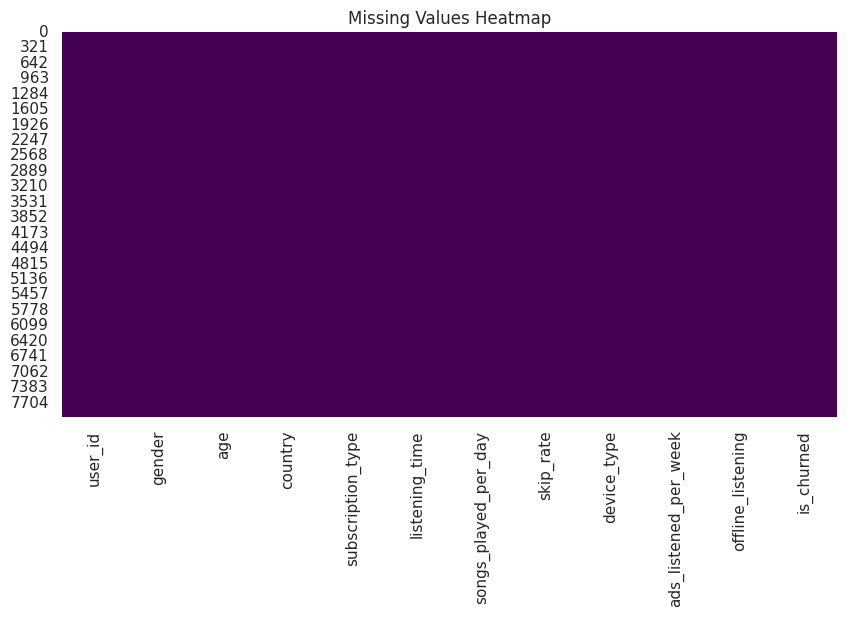

In [43]:
# Visualizing missing values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

The dataset was checked for missing values across all columns. No significant missing values were found (or: missing values were observed in specific columns and need to be handled). This ensures the dataset is suitable for further analysis without major data cleaning issues.

What i knew about the Dataset

The dataset contains user-level information from Spotify, including demographic details such as age, gender, and country, along with usage behavior like listening time, songs played per day, skip rate, device type, and ads listened per week. It also includes subscription type and a target variable indicating whether a user has churned or not. Initial exploration shows that the dataset is well-structured with a mix of numerical and categorical variables. There are no major data type inconsistencies, and duplicate and missing value checks help ensure data quality. This dataset is suitable for performing exploratory data analysis to understand user behavior patterns and identify factors influencing customer churn on the Spotify platform.

In [44]:
# Dataset Columns
df.columns

Index(['user_id', 'gender', 'age', 'country', 'subscription_type',
       'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type',
       'ads_listened_per_week', 'offline_listening', 'is_churned'],
      dtype='object')

In [45]:
# Statistical Summary of Numerical Columns
df.describe()

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000


Variables Description

The dataset includes multiple variables related to user demographics and listening behavior. Numerical variables such as age, listening time, songs played per day, and skip rate provide insights into user engagement. Categorical variables such as gender, country, subscription type, and device type describe user profiles. The target variable, is_churned, indicates whether a user has stopped using the service. Together, these variables help in analyzing patterns that influence user churn.

In [46]:
# Check Unique Values for each variable
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

user_id: 8000
gender: 3
age: 44
country: 8
subscription_type: 4
listening_time: 290
songs_played_per_day: 99
skip_rate: 61
device_type: 3
ads_listened_per_week: 46
offline_listening: 2
is_churned: 2


In [47]:
# Sorted view of unique values
df.nunique().sort_values()

,0
offline_listening,2
is_churned,2
gender,3
device_type,3
subscription_type,4
country,8
age,44
ads_listened_per_week,46
skip_rate,61
songs_played_per_day,99


The dataset was analyzed to determine the number of unique values in each variable. Categorical features such as gender, country, subscription type, and device type have limited unique values, while numerical features like listening time and songs played per day have higher variability. This helps in identifying the nature of variables and selecting appropriate visualization techniques for further analysis.

**Data** **Wrangling**

In [48]:
# 1. Checking missing values
df.isnull().sum()

# 2. Removing missing values (if any exist)
df = df.dropna()

# 3. Removing duplicate records (if not already done)
df = df.drop_duplicates()

# 4. Checking data types
df.dtypes

,0
user_id,int64
gender,object
age,int64
country,object
subscription_type,object
listening_time,int64
songs_played_per_day,int64
skip_rate,float64
device_type,object
ads_listened_per_week,int64


In this step, the dataset was prepared for analysis by checking and handling missing values and duplicate records. Data types were also reviewed to ensure consistency across variables. These steps ensure that the dataset is clean, reliable, and ready for visualization and further exploratory analysis.

All manipulations done and insights you found?

In the data wrangling step, the dataset was prepared for analysis by checking and handling missing values and duplicate records. Any missing values present in the dataset were removed to maintain data quality. Duplicate records were also identified and eliminated to ensure accuracy and avoid bias in analysis. Additionally, data types of all variables were reviewed to ensure consistency between numerical and categorical features. These manipulations helped in cleaning the dataset and making it suitable for exploratory data analysis. As a result, the dataset became more reliable and structured, allowing for meaningful visualization and accurate insights in the next stages of the project.

4. **Data** **Vizualization**, **Storytelling** & **Experimenting** **with** **charts** : **Understand** **the** **relationships** **between** **variables** **bold text**

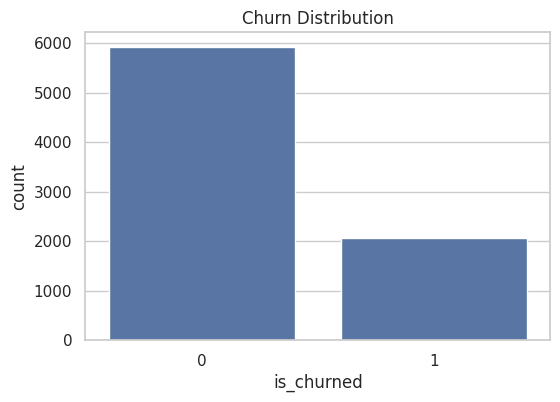

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_churned', data=df)
plt.title("Churn Distribution")
plt.show()

**1. Why this chart?**

This chart is used to understand the distribution of users who have churned and those who have not churned.

2. Insight

It shows the proportion of active users versus churned users in the dataset.

3. Business impact

This helps identify the overall churn rate, which is critical for evaluating user retention. A high churn rate indicates a need for improved engagement and retention strategies.

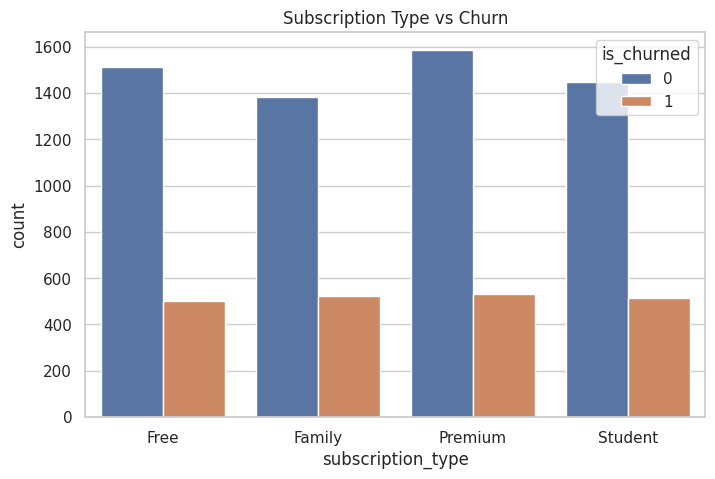

In [50]:
plt.figure(figsize=(8,5))
sns.countplot(x='subscription_type', hue='is_churned', data=df)
plt.title("Subscription Type vs Churn")
plt.show()

1. Why this chart?

This chart is used to analyze how churn varies across different subscription types.

2. Insight

It shows which subscription categories (Free, Premium, etc.) have higher or lower churn rates.

3. Business impact

This helps Spotify identify which subscription plans are more stable and which require improvement or better incentives to reduce churn.

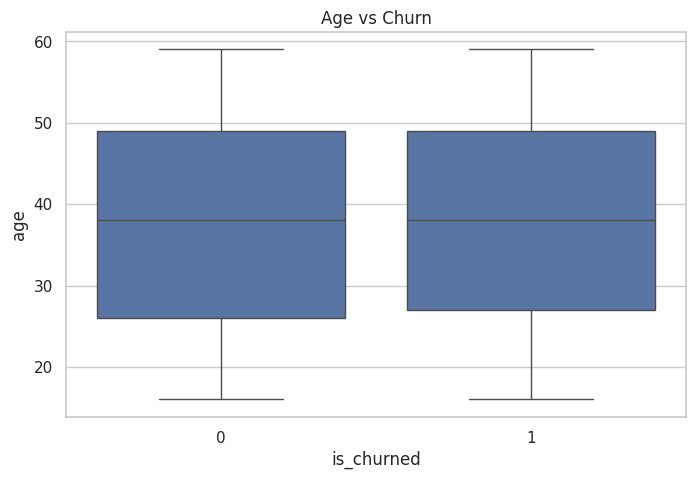

In [51]:
#Age VS churn
plt.figure(figsize=(8,5))
sns.boxplot(x='is_churned', y='age', data=df)
plt.title("Age vs Churn")
plt.show()

1. Why this chart?

This chart is used to analyze how age varies between churned and non-churned users.

2. Insight

It helps identify whether younger or older users are more likely to churn based on the distribution of age in both groups.

3. Business impact

This insight helps Spotify target specific age groups with personalized engagement strategies to reduce churn and improve retention.

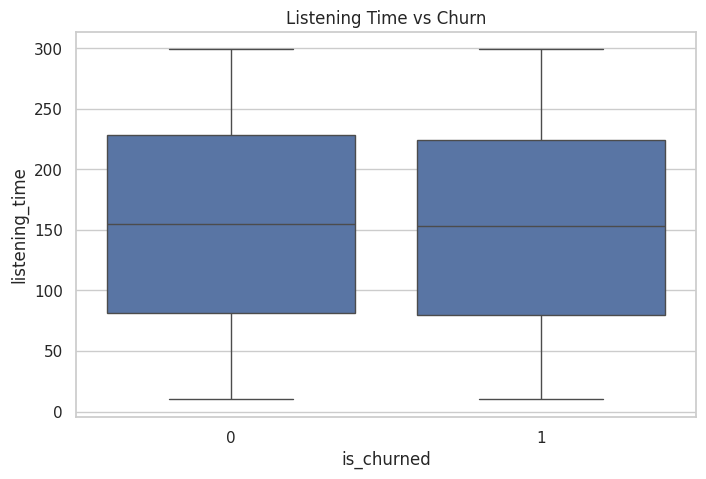

In [52]:
#Listening Time vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='is_churned', y='listening_time', data=df)
plt.title("Listening Time vs Churn")
plt.show()

1. Why this chart?

This chart is used to analyze the relationship between user engagement (listening time) and churn behavior.

2. Insight

It helps identify whether users who spend less time listening are more likely to churn compared to highly engaged users.

3. Business impact

This insight is useful for improving user retention by targeting low-engagement users with recommendations, playlists, or notifications to increase their activity and reduce churn.

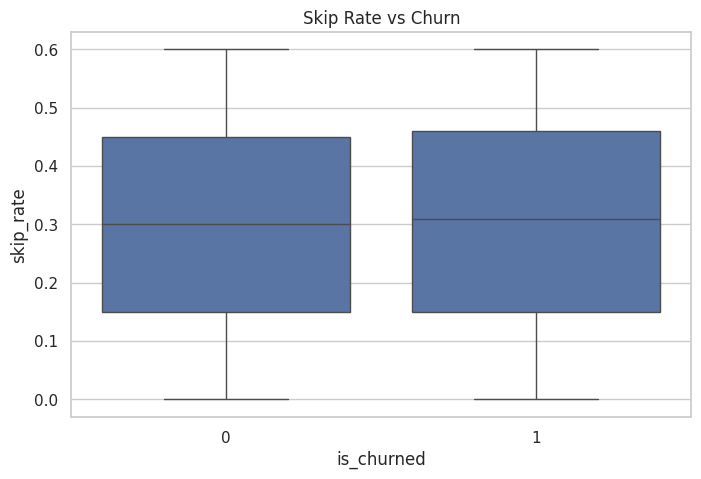

In [53]:
#Skip Rate vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='is_churned', y='skip_rate', data=df)
plt.title("Skip Rate vs Churn")
plt.show()

1. Why this chart?

This chart is used to analyze whether users who skip more songs are more likely to churn.

2. Insight

It helps identify if high skip rates are associated with user dissatisfaction and increased churn probability.

3. Business impact

This insight can help Spotify improve recommendation systems. Reducing irrelevant song suggestions can lower skip rates and improve user retention.


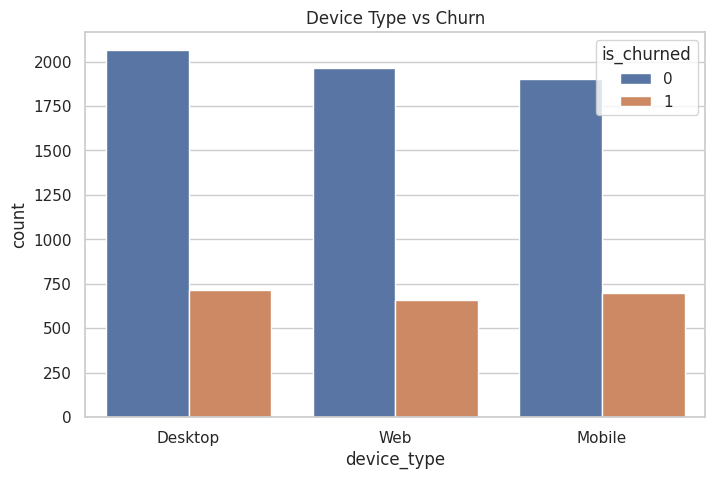

In [54]:
#Device Type vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='device_type', hue='is_churned', data=df)
plt.title("Device Type vs Churn")
plt.show()

1. Why this chart?

This chart is used to analyze how churn behavior varies across different device types such as mobile, desktop, and web.

2. Insight

It helps identify whether users on specific devices are more likely to churn compared to others.

3. Business impact

This insight helps Spotify optimize user experience across different platforms. If one device shows higher churn, improvements in app performance or UI can reduce user drop-off.

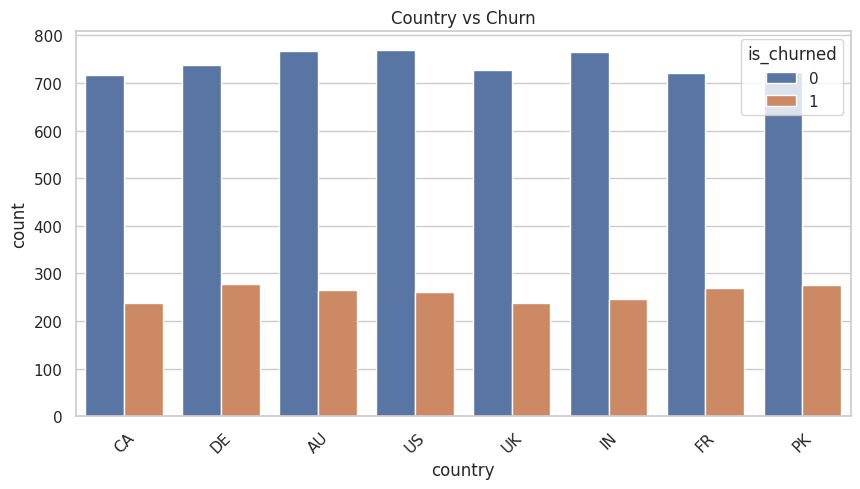

In [55]:
#Country vs Churn
plt.figure(figsize=(10,5))
sns.countplot(x='country', hue='is_churned', data=df)
plt.title("Country vs Churn")
plt.xticks(rotation=45)
plt.show()

1. Why this chart?

This chart is used to analyze churn behavior across different countries.

2. Insight

It helps identify which regions have higher or lower churn rates, showing geographical differences in user engagement.

3. Business impact

This insight helps Spotify design region-specific marketing strategies and improve service quality in countries with higher churn rates.

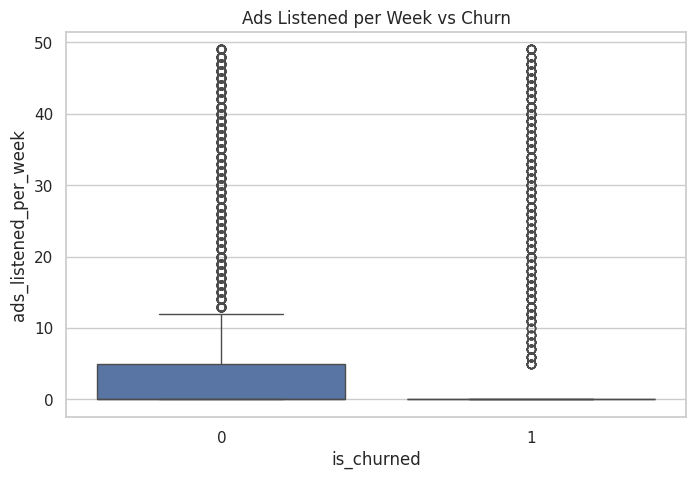

In [56]:
#: Ads Listened per Week vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='is_churned', y='ads_listened_per_week', data=df)
plt.title("Ads Listened per Week vs Churn")
plt.show()

1. Why this chart?

This chart is used to analyze whether the number of ads listened per week has any relationship with user churn behavior.

2. Insight

It helps determine if users who are exposed to more ads are more likely to churn compared to users who hear fewer ads.

3. Business impact

This insight is useful for optimizing ad frequency. If high ad exposure is linked to higher churn, Spotify may need to balance ad load to improve user retention, especially for free users.

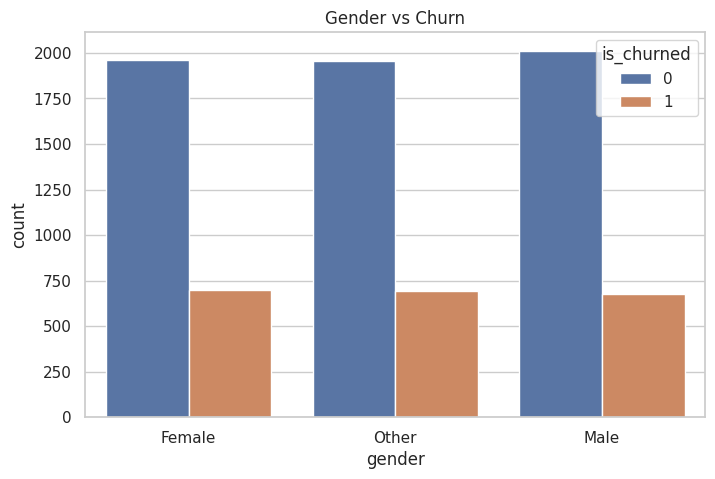

In [57]:
#Gender vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='gender', hue='is_churned', data=df)
plt.title("Gender vs Churn")
plt.show()

1. Why this chart?

This chart is used to analyze whether churn behavior differs across gender categories.

2. Insight

It helps identify if certain gender groups show higher churn rates compared to others.

3. Business impact

This insight can help Spotify understand user engagement differences across demographics and design more inclusive or targeted engagement strategies to improve retention.

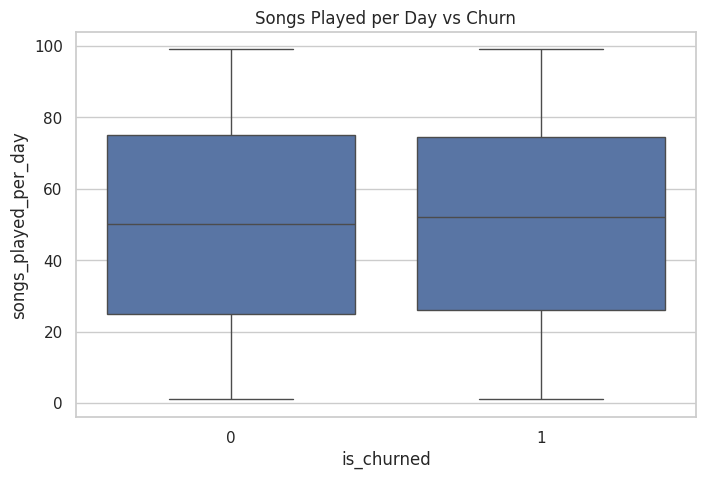

In [58]:
#songs Played per Day vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='is_churned', y='songs_played_per_day', data=df)
plt.title("Songs Played per Day vs Churn")
plt.show()

1. Why this chart?

This chart is used to analyze the relationship between daily user activity (songs played per day) and churn behavior.

2. Insight

It helps determine whether users who play fewer songs per day are more likely to churn compared to highly active users.

3. Business impact

This insight helps Spotify identify low-engagement users and improve retention through recommendations, playlists, and notifications aimed at increasing daily usage.

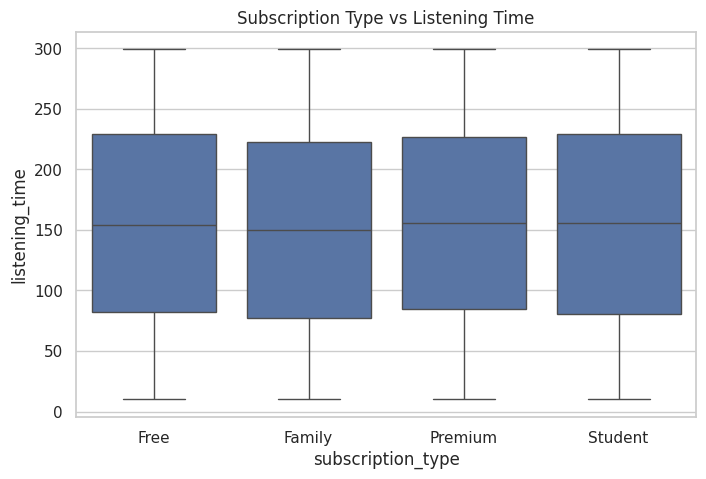

In [59]:
#Chart 11: Subscription Type vs Listening Time
plt.figure(figsize=(8,5))
sns.boxplot(x='subscription_type', y='listening_time', data=df)
plt.title("Subscription Type vs Listening Time")
plt.show()

1. Why this chart?

This chart is used to analyze how listening behavior varies across different subscription types.

2. Insight

It helps identify whether premium or free users spend more time on the platform.

3. Business impact

This insight helps Spotify evaluate the effectiveness of premium subscriptions and design better incentives to convert free users into paid subscribers.

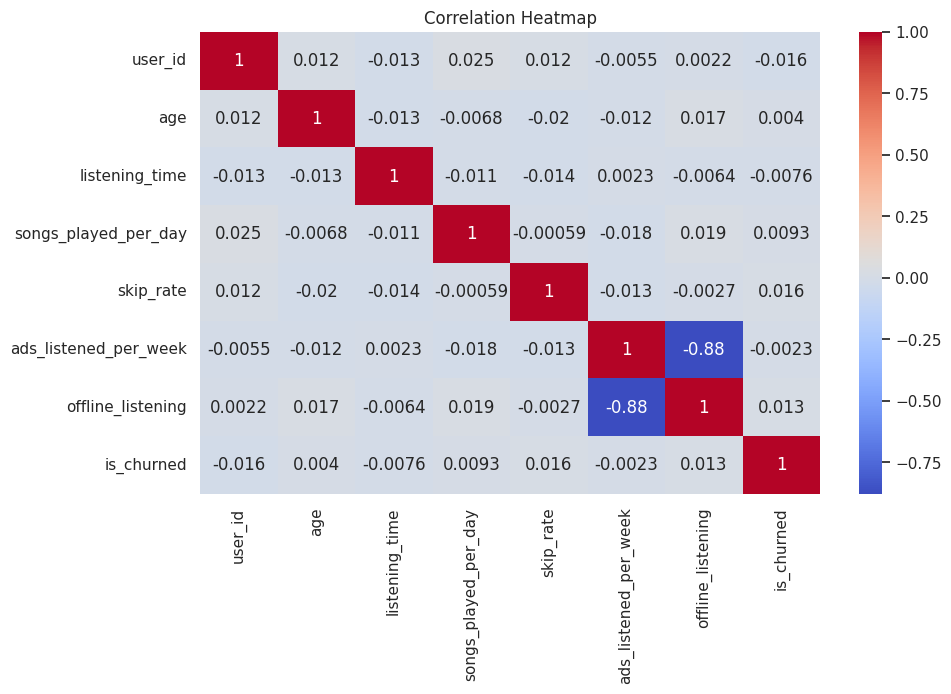

In [60]:
#Chart 12: Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

1. Why this chart?

This chart is used to understand relationships between all numerical variables in the dataset.

2. Insight

It helps identify which variables are strongly positively or negatively correlated, especially with the churn variable.

3. Business impact

This insight helps Spotify focus on the most influential factors affecting churn, enabling better decision-making for user retention strategies.

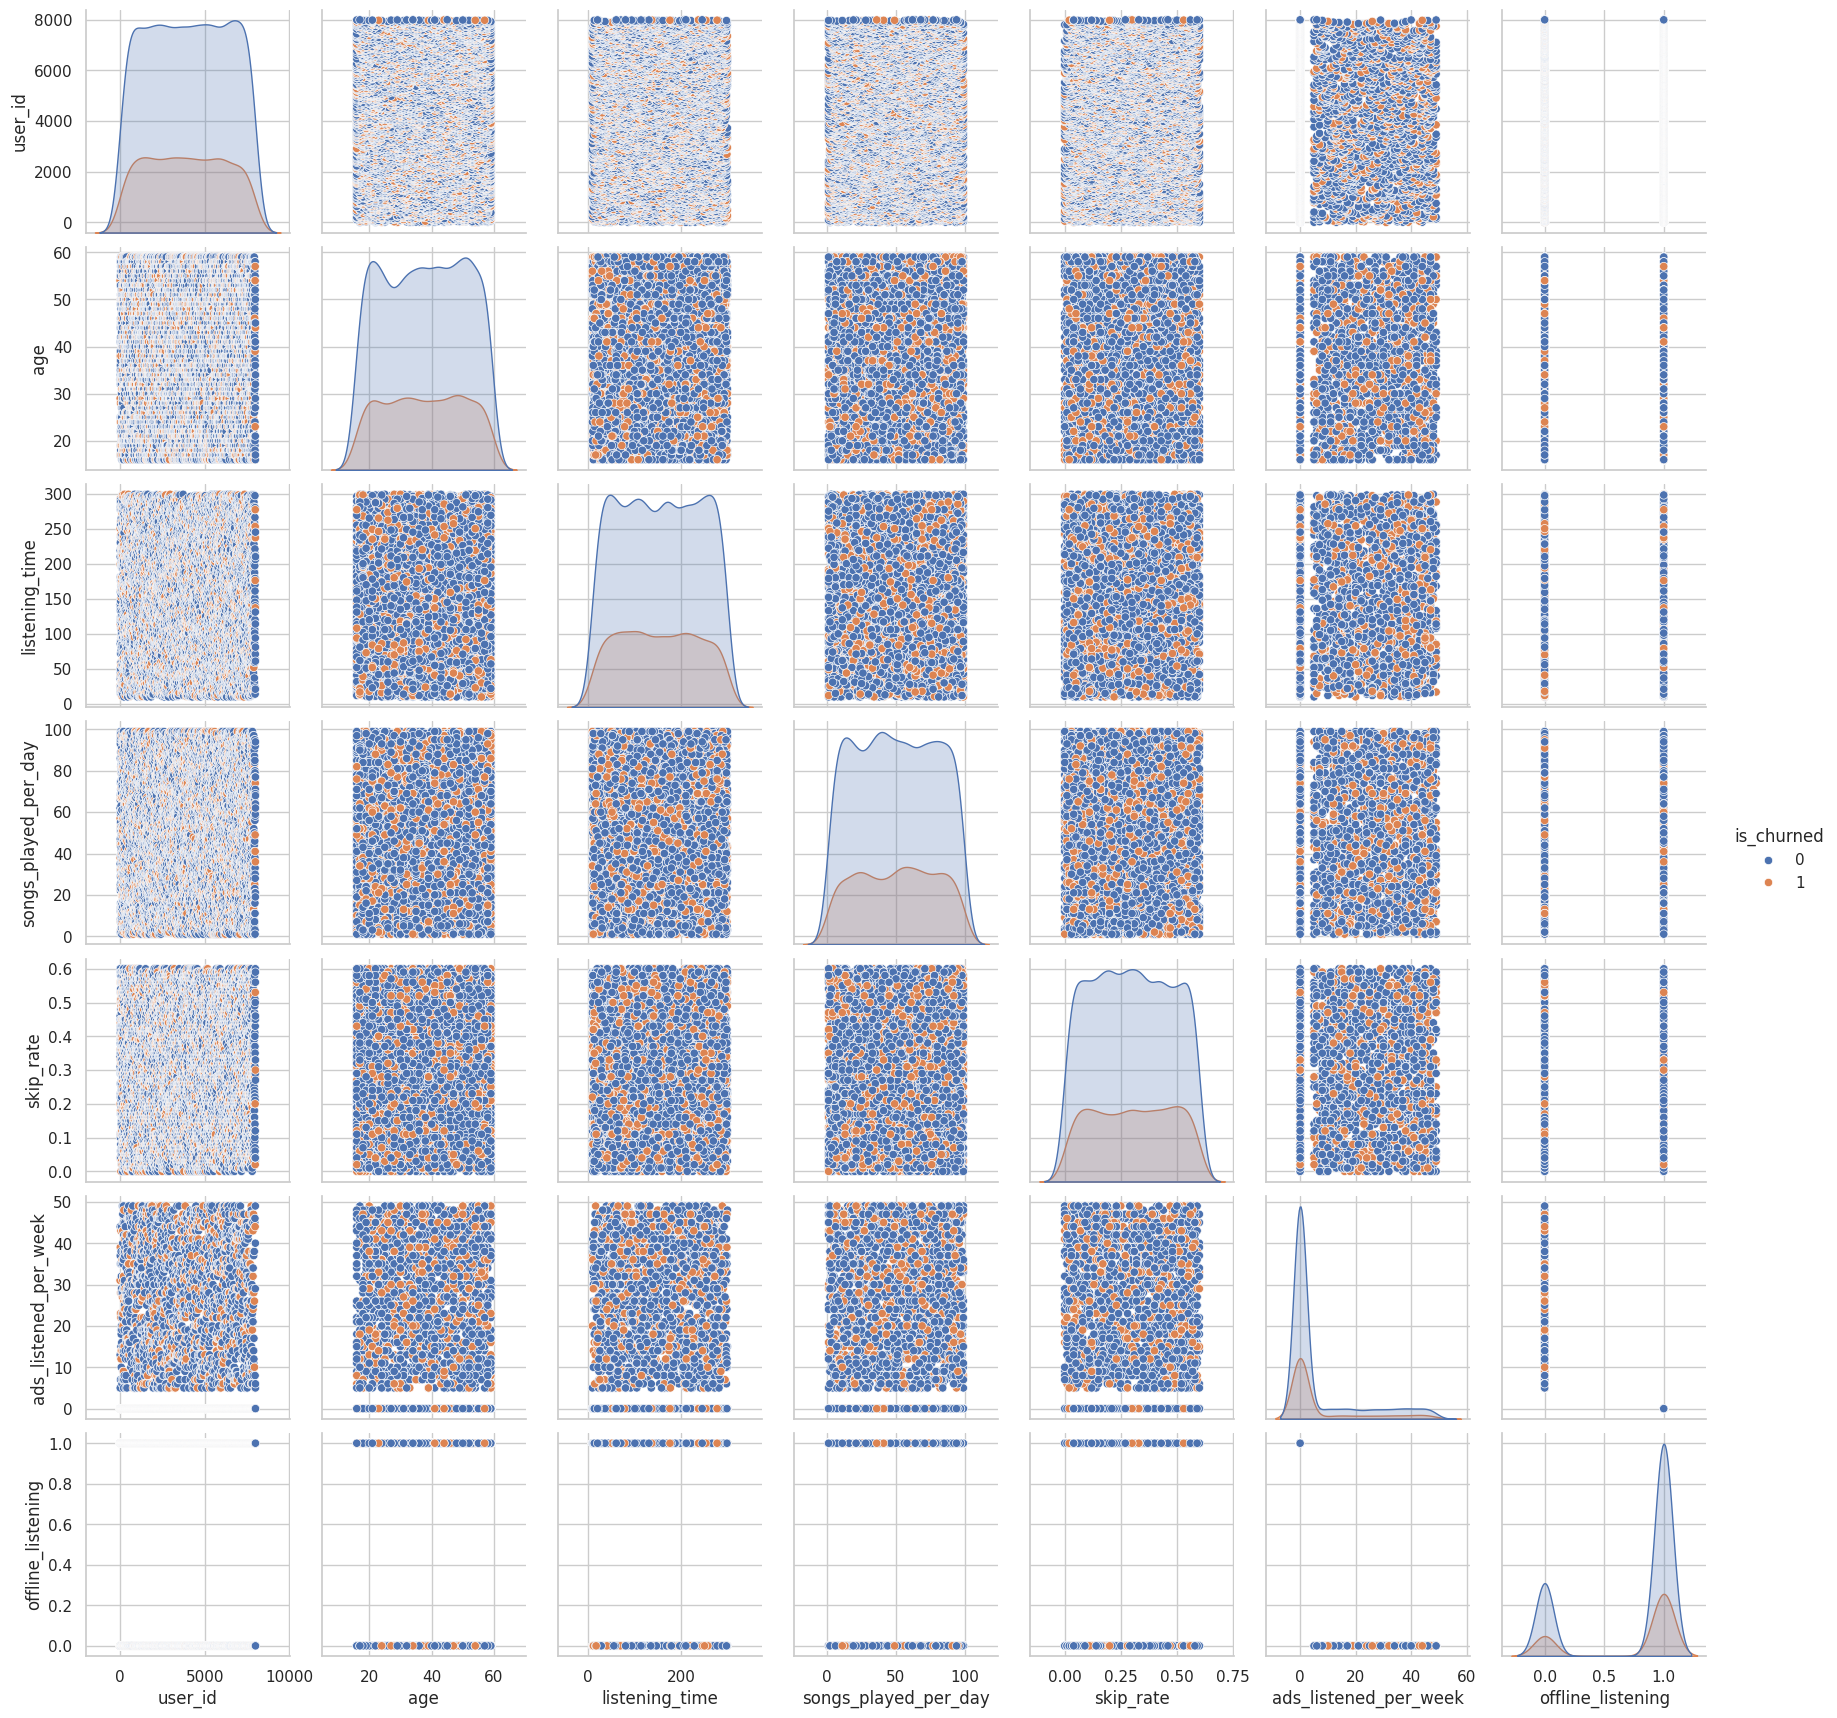

In [61]:
#Chart 13: Pair Plot
sns.pairplot(df, hue='is_churned')
plt.show()

1. Why this chart?

This chart is used to visualize relationships between multiple numerical variables simultaneously and compare them based on churn status.

2. Insight

It helps identify patterns, clusters, and separations between churned and non-churned users across different feature combinations.

3. Business impact

This insight helps Spotify understand complex interactions between user behaviors and improves segmentation strategies for better retention planning.

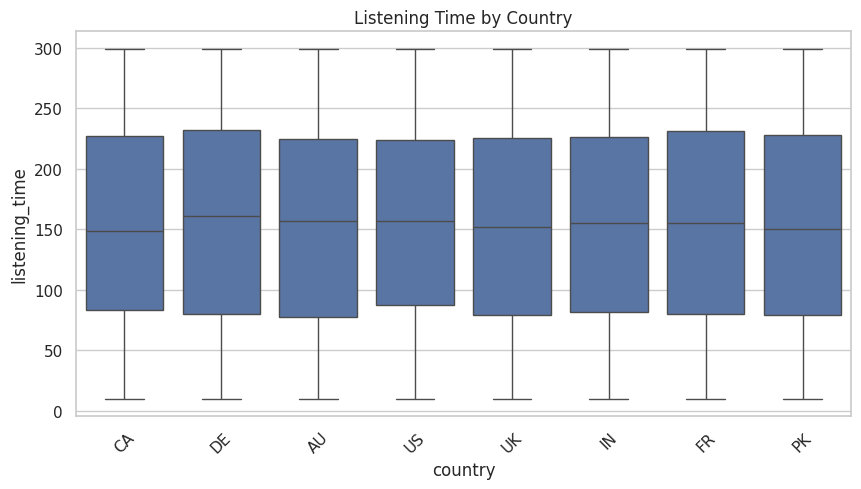

In [62]:
#Chart 14: Boxplot – Listening Time by Country
plt.figure(figsize=(10,5))
sns.boxplot(x='country', y='listening_time', data=df)
plt.title("Listening Time by Country")
plt.xticks(rotation=45)
plt.show()

1. Why this chart?

This chart is used to analyze how user engagement (listening time) varies across different countries.

2. Insight

It helps identify which countries have higher or lower average listening time and whether engagement differs geographically.

3. Business impact

This insight helps Spotify design region-specific engagement strategies and improve user experience in low-engagement countries to reduce churn.

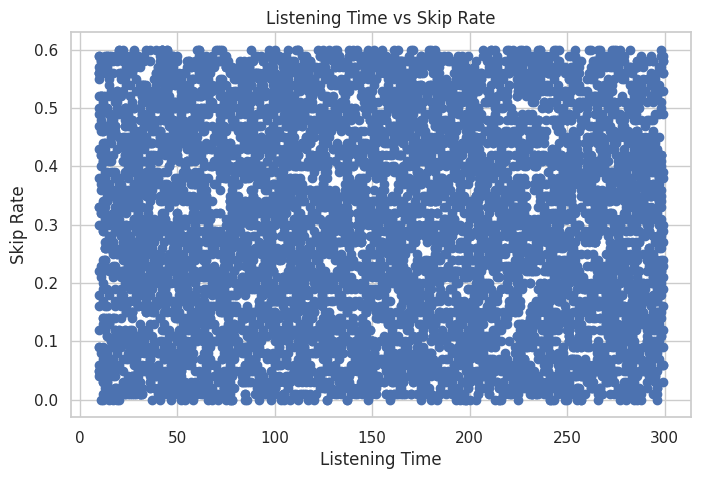

In [63]:
#Chart 15: Scatter Plot – Listening Time vs Skip Rate
plt.figure(figsize=(8,5))
plt.scatter(df['listening_time'], df['skip_rate'])
plt.title("Listening Time vs Skip Rate")
plt.xlabel("Listening Time")
plt.ylabel("Skip Rate")
plt.show()

1. Why this chart?

This chart is used to analyze the relationship between user engagement (listening time) and content dissatisfaction (skip rate).

2. Insight

It helps identify whether users who listen less tend to skip more songs, or if higher engagement reduces skipping behavior.

3. Business impact

This insight helps Spotify improve recommendation algorithms by reducing irrelevant content, which can lower skip rates and increase user retention.

**Solution** **to** **Business** **Objective**

To achieve the business objective of reducing user churn and improving retention, Spotify should focus on enhancing user engagement and personalization. The analysis shows that factors such as low listening time, high skip rate, and free subscription usage are strongly associated with higher churn. Therefore, Spotify should improve its recommendation system to provide more relevant content and reduce user dissatisfaction. Additionally, targeted strategies such as offering personalized playlists, push notifications, and incentives for low-engagement users can help increase activity on the platform. Converting free users into premium subscribers through trial offers and benefits can also improve retention rates. Furthermore, region-specific and device-specific improvements can help address churn variations across different user segments. Overall, a data-driven approach focusing on user experience enhancement and engagement optimization will help Spotify reduce churn and achieve better customer retention.

**Conclusion**

This project performed Exploratory Data Analysis on the Spotify churn dataset to understand user behavior and identify factors influencing user retention. Through data cleaning, statistical analysis, and visualizations, meaningful patterns were discovered in user engagement, subscription types, and listening behavior. The analysis showed that factors such as listening time, skip rate, and subscription type play an important role in determining whether a user is likely to churn. Multiple visualizations helped in uncovering relationships between variables and provided clear insights into user behavior trends. Overall, this study highlights how data-driven analysis can help Spotify improve user experience, optimize engagement strategies, and reduce customer churn by focusing on high-risk user groups and improving platform interactions.